<a href="https://colab.research.google.com/github/anfaltanveer25/Data-Cleaning-and-Exploratory-Analysis-VORTEXTECH-/blob/main/Data_Cleaning_and_Exploratory_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading the Dataset

In this step, the Wholesale Customers dataset is loaded using Pandas. The first few rows are displayed to understand the structure of the dataset, and the dataset information is checked to identify the number of rows, columns, and data types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  load dataset
df=pd.read_csv('Wholesale customers data.csv')
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


## Checking Missing Values and Duplicate Records

This step checks whether the dataset contains any missing values or duplicate records. The result showed that the dataset has no missing values and no duplicate rows.

In [2]:
#  Missing values
print(df.isnull().sum()) # sum of missing rows
df.duplicated().sum()  #duplicate column


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


np.int64(0)

## Handling Missing Values

Any missing values in numerical columns are replaced with the column mean. Since there are no categorical columns in this dataset, no categorical missing value handling was required.

In [3]:

#  Handle missing values for numerical columns

numerical_cols=[
  'Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

for col in numerical_cols:
     if df[col].isnull().sum() > 0:
         df[col].fillna(df[col].mean())

print("Null values are handled in numerical columns.")


Null values are handled in numerical columns.


In [4]:

#Handle missing values for categorical columns
categorical_df = df.select_dtypes(include=['object'])
for col in categorical_df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0])

print("Null values are handled in categorical columns.")


Null values are handled in categorical columns.


## Correcting Data Types

The numerical columns are converted to numeric data types to ensure consistency and avoid errors during data analysis and visualization.

In [5]:
#correct data types for numerical columns
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print("Data types are corrected for numerical columns.")


Data types are corrected for numerical columns.


## Descriptive Statistics

Descriptive statistics are generated to summarize the dataset. These statistics include count, mean, standard deviation, minimum, maximum, and quartile values for each numerical feature.

In [6]:

 # descriptive statistics

print(df.describe())
print(df.select_dtypes(include='object').columns)



          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper    Delicassen  
count    440.000000        440.000000    440.000000  
mean    3071.931818       2881.493182   1524.870455  
std     4854.673333       4767.854448   2820.105937  
min       25.000000          3.000000      3.000000  
25%      742.250000        256.750000    408.

## Histogram Visualization

A histogram is used to visualize the distribution of numerical variables in the dataset. It helps identify the spread of data, skewness, and the presence of potential outliers.

### Observation

Most numerical features are positively skewed, indicating that many customers have lower spending values while a few customers have very high spending amounts. This suggests the presence of outliers in the dataset.

======================Visuialization======================


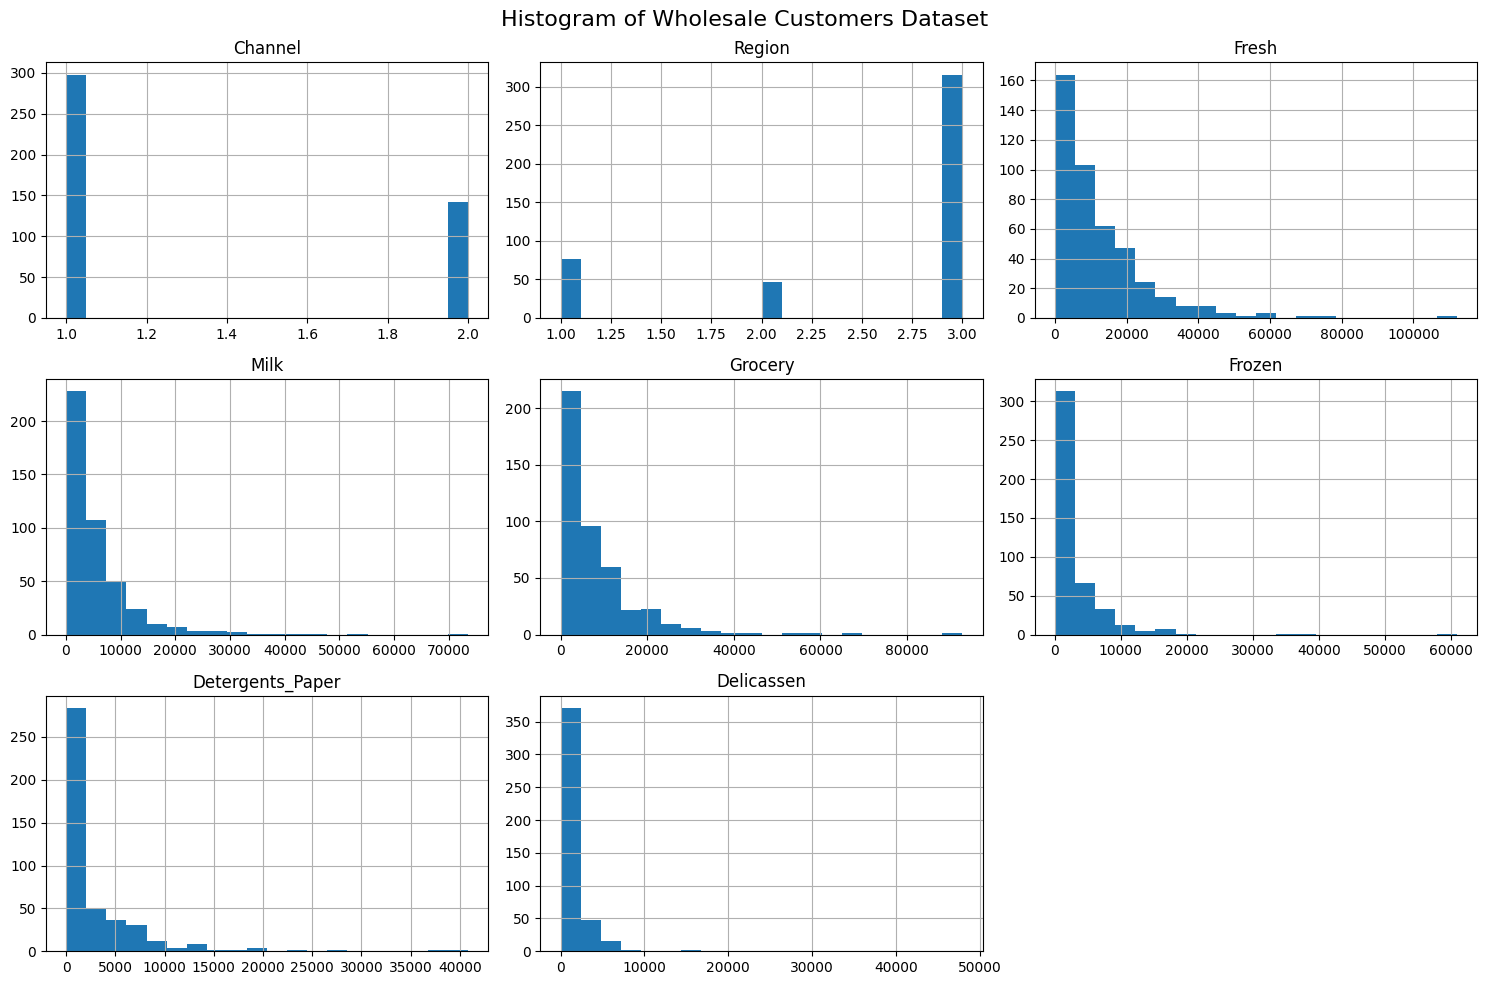

<Figure size 640x480 with 0 Axes>

In [7]:

print("======================Visuialization======================")

df.hist(figsize=(15,10), bins=20)

plt.suptitle("Histogram of Wholesale Customers Dataset", fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig('histogram.png')